# Analisis estadistico y seleccion de features
Base: `base_modelado.parquet`. Objetivo: generar graficos clave y priorizar predictores para `tipo_violencia` y `nivel_riesgo_victima`.

## 1) Librerias

In [1]:
# !pip install pandas pyarrow numpy seaborn matplotlib scipy scikit-learn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal
from sklearn.feature_selection import mutual_info_classif

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 180)
sns.set(style="whitegrid")


## 2) Carga de base final y maestro ubigeo
Se carga la base final y se enriquece con nombres de departamento/provincia/distrito usando `ubigeo_trabajar.csv`.

In [2]:
PARQUET_PATH = "/home/munasqa/MAESTRIA/opencode/base_modelado.parquet"
UBIGEO_PATH = "/home/munasqa/MAESTRIA/opencode/ubigeo_trabajar.csv"

df = pd.read_parquet(PARQUET_PATH)
ub = pd.read_csv(UBIGEO_PATH, dtype=str)

ub.columns = [c.strip().lower() for c in ub.columns]
for c in ["codigo_dpto","codigo_prov","codigo_dist"]:
    ub[c] = ub[c].astype(str).str.strip().str.zfill(2)
ub["dpto"] = ub["dpto"].astype(str).str.strip()
ub["prov"] = ub["prov"].astype(str).str.strip()
ub["dist"] = ub["dist"].astype(str).str.strip()
ub["ubigeo_codigo"] = ub["codigo_dpto"] + ub["codigo_prov"] + ub["codigo_dist"]
ub["ubigeo_nombre"] = ub["dpto"] + " | " + ub["prov"] + " | " + ub["dist"]

if "nivel_de_riesgo_victima" in df.columns and "nivel_riesgo_victima" not in df.columns:
    df = df.rename(columns={"nivel_de_riesgo_victima":"nivel_riesgo_victima"})

for c in ["dpto_domicilio","prov_domicilio","dist_domicilio"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.zfill(2)

if all(c in df.columns for c in ["dpto_domicilio","prov_domicilio","dist_domicilio"]):
    df["ubigeo_codigo"] = df["dpto_domicilio"] + df["prov_domicilio"] + df["dist_domicilio"]

# evitar conflictos si la base ya trae estas columnas
for c in ["dpto", "prov", "dist", "ubigeo_nombre"]:
    if c in df.columns:
        df = df.drop(columns=[c])

df = df.merge(
    ub[["ubigeo_codigo","dpto","prov","dist","ubigeo_nombre"]].drop_duplicates(),
    on="ubigeo_codigo",
    how="left"
)

print(df.shape)
print("Targets presentes:", [c for c in ["tipo_violencia","nivel_riesgo_victima"] if c in df.columns])
if "ubigeo_nombre" in df.columns:
    print("Match ubigeo_nombre:", round(df["ubigeo_nombre"].notna().mean()*100,2), "%")
else:
    print("ubigeo_nombre no se genero; revisar llaves dpto/prov/dist.")


(932860, 132)
Targets presentes: ['tipo_violencia', 'nivel_riesgo_victima']
Match ubigeo_nombre: 99.99 %


## 3) Diccionario de targets y distribucion
Se mapean codigos a etiquetas legibles para usar en todos los graficos. En esta version las clases ya estan recodificadas a base 0.

In [3]:
map_tipo_violencia = {0:"Psicologica",1:"Fisica",2:"Sexual"}
map_nivel_riesgo = {0:"Bajo",1:"Medio",2:"Alto"}

df["tipo_violencia"] = pd.to_numeric(df["tipo_violencia"], errors="coerce")
df["nivel_riesgo_victima"] = pd.to_numeric(df["nivel_riesgo_victima"], errors="coerce")

df["tipo_violencia_lbl"] = df["tipo_violencia"].map(map_tipo_violencia)
df["nivel_riesgo_victima_lbl"] = df["nivel_riesgo_victima"].map(map_nivel_riesgo)

display(df[["tipo_violencia_lbl","nivel_riesgo_victima_lbl"]].head())


,tipo_violencia_lbl,nivel_riesgo_victima_lbl
0,Fisica,Medio
1,Psicologica,Bajo
2,Psicologica,Bajo
3,Sexual,Medio
4,Sexual,Medio


## 4) Graficos de distribucion de targets

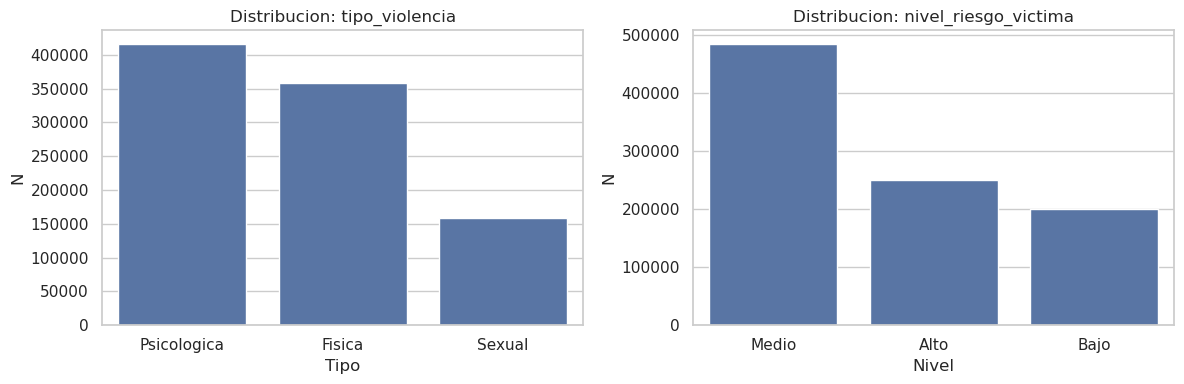

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(data=df, x="tipo_violencia_lbl", order=df["tipo_violencia_lbl"].value_counts().index, ax=ax[0])
ax[0].set_title("Distribucion: tipo_violencia")
ax[0].set_xlabel("Tipo")
ax[0].set_ylabel("Denuncias")

sns.countplot(data=df, x="nivel_riesgo_victima_lbl", order=df["nivel_riesgo_victima_lbl"].value_counts().index, ax=ax[1])
ax[1].set_title("Distribucion: nivel_riesgo_victima")
ax[1].set_xlabel("Nivel")
ax[1].set_ylabel("Denuncias")

plt.tight_layout()
plt.show()


## 5) Crosstab y graficos: nivel de riesgo vs tipo de violencia

tipo_violencia_lbl,Fisica,Psicologica,Sexual
nivel_riesgo_victima_lbl,,,
Alto,115083,68577,65776
Bajo,51428,132566,15573
Medio,191975,214165,77717


tipo_violencia_lbl,Fisica,Psicologica,Sexual
nivel_riesgo_victima_lbl,,,
Alto,46.14,27.49,26.37
Bajo,25.77,66.43,7.80
Medio,39.68,44.26,16.06


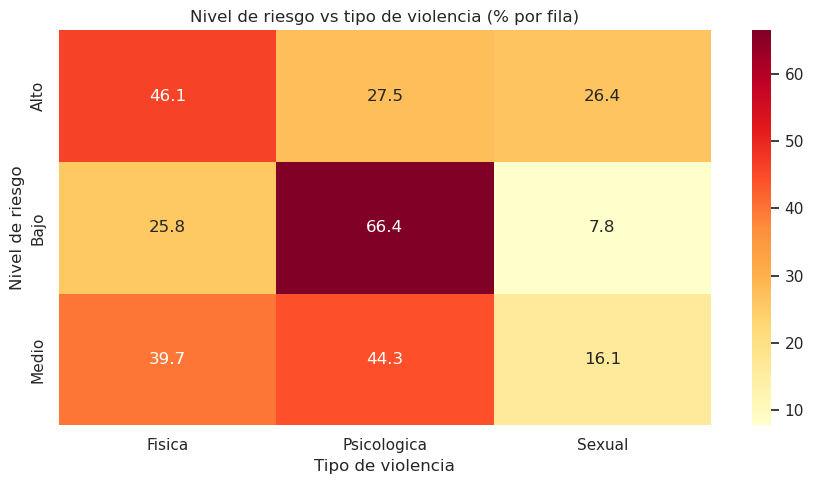

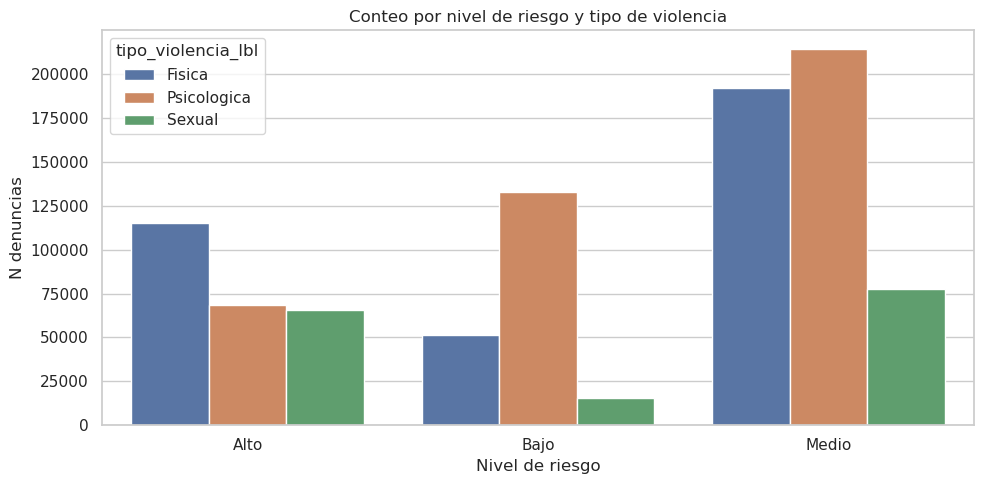

In [5]:
ct_count = pd.crosstab(df["nivel_riesgo_victima_lbl"], df["tipo_violencia_lbl"], dropna=False)
ct_row_pct = pd.crosstab(df["nivel_riesgo_victima_lbl"], df["tipo_violencia_lbl"], normalize="index", dropna=False) * 100

display(ct_count)
display(ct_row_pct.round(2))

plt.figure(figsize=(9,5))
sns.heatmap(ct_row_pct, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Nivel de riesgo vs tipo de violencia (% por fila)")
plt.xlabel("Tipo de violencia")
plt.ylabel("Nivel de riesgo")
plt.tight_layout()
plt.show()

ct_long = ct_count.reset_index().melt(id_vars="nivel_riesgo_victima_lbl", var_name="tipo_violencia_lbl", value_name="n")
plt.figure(figsize=(10,5))
sns.barplot(data=ct_long, x="nivel_riesgo_victima_lbl", y="n", hue="tipo_violencia_lbl")
plt.title("Conteo por nivel de riesgo y tipo de violencia")
plt.xlabel("Nivel de riesgo")
plt.ylabel("N denuncias")
plt.tight_layout()
plt.show()


## 6) Graficos geograficos
Top 20 departamentos y top 20 ubigeos con mayor numero de denuncias.

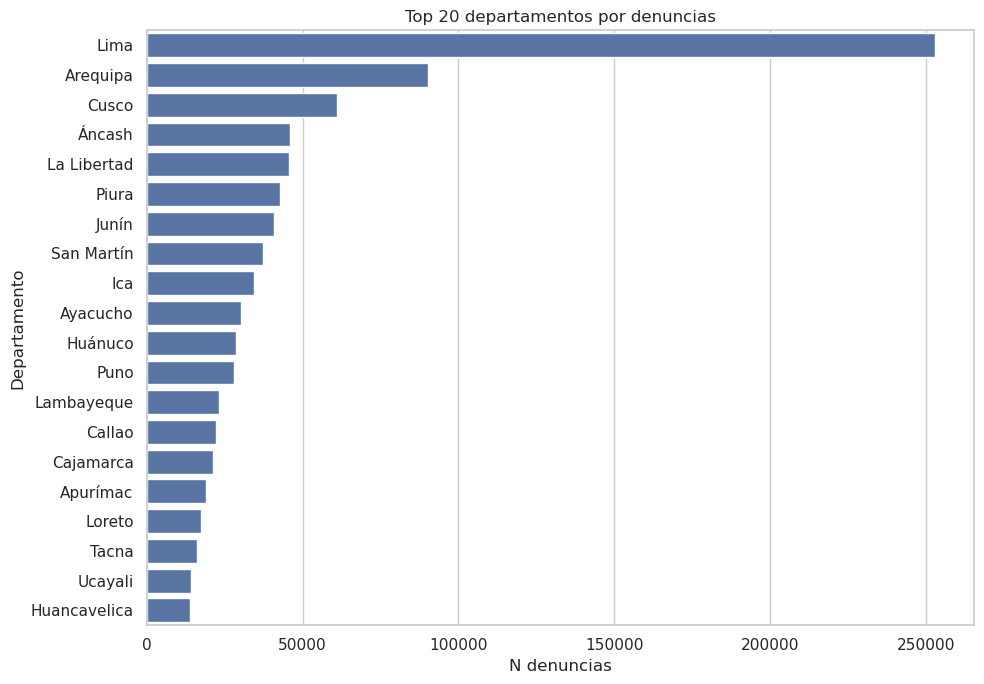

,n_denuncias
dpto,
Lima,252851
Arequipa,90358
Cusco,61045
Áncash,46036
La Libertad,45622
Piura,42605
Junín,40958
San Martín,37316
Ica,34311


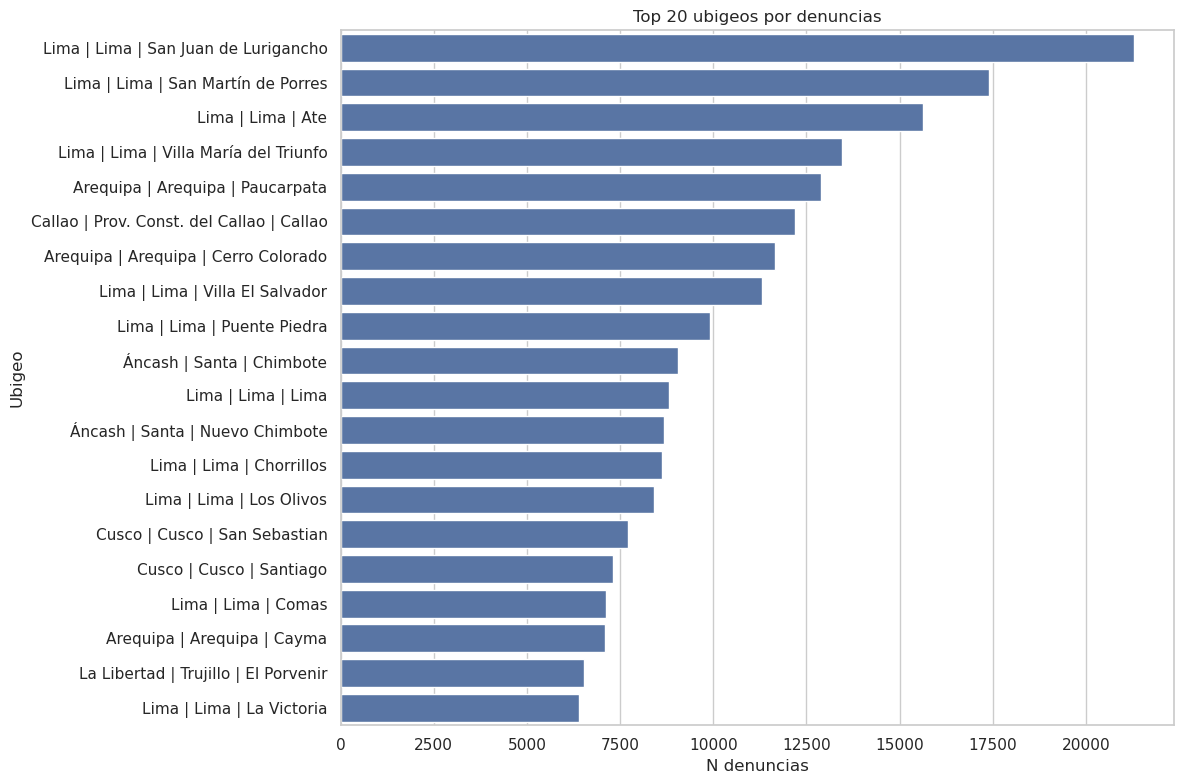

,n_denuncias
ubigeo_nombre,
Lima | Lima | San Juan de Lurigancho,21296
Lima | Lima | San Martín de Porres,17385
Lima | Lima | Ate,15630
Lima | Lima | Villa María del Triunfo,13460
Arequipa | Arequipa | Paucarpata,12888
Callao | Prov. Const. del Callao | Callao,12185
Arequipa | Arequipa | Cerro Colorado,11664
Lima | Lima | Villa El Salvador,11318
Lima | Lima | Puente Piedra,9902


In [6]:
top_dpto = df["dpto"].fillna("Sin dato").value_counts().head(20)

plt.figure(figsize=(10,7))
sns.barplot(x=top_dpto.values, y=top_dpto.index, orient="h")
plt.title("Top 20 departamentos por denuncias")
plt.xlabel("N denuncias")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

display(top_dpto.to_frame("n_denuncias"))

top_ubigeo = df["ubigeo_nombre"].fillna("Sin dato").value_counts().head(20)
plt.figure(figsize=(12,8))
sns.barplot(x=top_ubigeo.values, y=top_ubigeo.index, orient="h")
plt.title("Top 20 ubigeos por denuncias")
plt.xlabel("N denuncias")
plt.ylabel("Ubigeo")
plt.tight_layout()
plt.show()

display(top_ubigeo.to_frame("n_denuncias"))


## 7) Serie temporal
Si no existe `fecha_ingreso`, se reconstruye usando `anio` y `mes`.

Puntos de serie: 69


,fecha_ts,n_denuncias
0,2020-01-01,18373
1,2020-02-01,17082
2,2020-03-01,9311
3,2020-07-01,5639
4,2020-08-01,4876


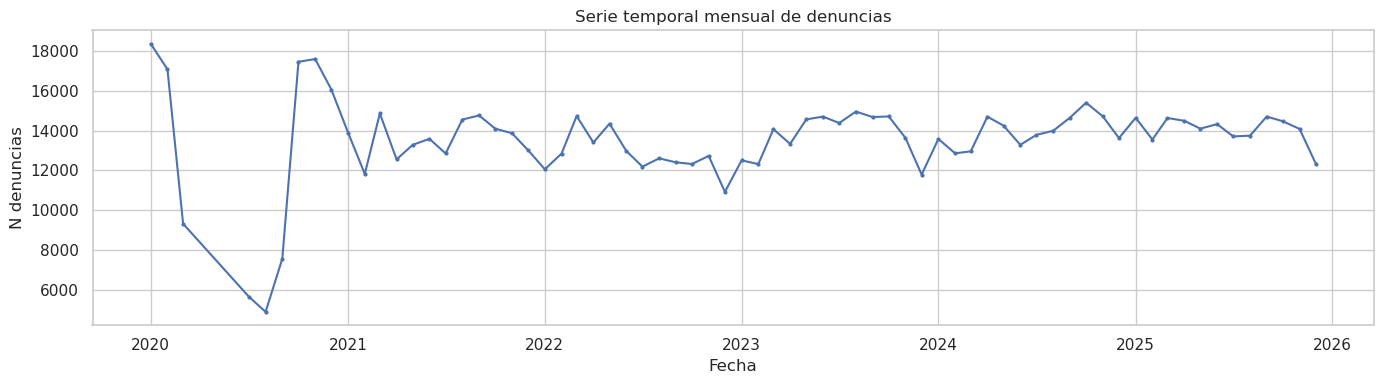

In [7]:
if "fecha_ingreso" in df.columns:
    df["fecha_ts"] = pd.to_datetime(df["fecha_ingreso"], errors="coerce")
elif all(c in df.columns for c in ["anio","mes"]):
    tmp = pd.DataFrame({"anio":pd.to_numeric(df["anio"], errors="coerce"),"mes":pd.to_numeric(df["mes"], errors="coerce")})
    df["fecha_ts"] = pd.to_datetime(dict(year=tmp["anio"], month=tmp["mes"], day=1), errors="coerce")
else:
    df["fecha_ts"] = pd.NaT

serie = df.dropna(subset=["fecha_ts"]).groupby(df["fecha_ts"].dt.to_period("M")).size().reset_index(name="n_denuncias")
serie["fecha_ts"] = pd.to_datetime(serie["fecha_ts"].astype(str))
print("Puntos de serie:", len(serie))
display(serie.head())

plt.figure(figsize=(14,4))
plt.plot(serie["fecha_ts"], serie["n_denuncias"], marker="o", markersize=2)
plt.title("Serie temporal mensual de denuncias")
plt.xlabel("Fecha")
plt.ylabel("N denuncias")
plt.tight_layout()
plt.show()


## 8) Que es Mutual Information (MI)
**Mutual Information (MI)** mide cuanta informacion aporta una variable para predecir el target.
- MI = 0: no aporta informacion.
- MI > 0: aporta informacion (detecta relaciones lineales y no lineales).
Se usa como ranking preliminar de predictores; no implica causalidad.

## 9) Seleccion de features: asociacion estadistica + MI

In [8]:
targets_modelo = ["tipo_violencia", "nivel_riesgo_victima"]
leakage_obvio = ["tipo_violencia_lbl", "nivel_riesgo_victima_lbl"]
features_candidatas = [c for c in df.columns if c not in set(targets_modelo + leakage_obvio)]

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        return np.nan, np.nan
    chi2, p, _, _ = chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    r, k = tabla.shape
    denom = min(r-1, k-1)
    v = np.sqrt((chi2 / n) / denom) if denom > 0 else np.nan
    return v, p

rankings = {}

for t in targets_modelo:
    y = pd.to_numeric(df[t], errors="coerce")

    rows_cat = []
    for c in features_candidatas:
        if str(df[c].dtype) in ["object", "category"]:
            v, p = cramers_v(df[c].astype(str), y.astype(str))
            rows_cat.append((c, v, p))
    r_cat = pd.DataFrame(rows_cat, columns=["feature", "cramers_v", "p_value"]).dropna().sort_values("cramers_v", ascending=False)

    X = df[features_candidatas].copy()
    for c in X.columns:
        if str(X[c].dtype) in ["object", "category"]:
            X[c] = X[c].astype(str).fillna("desconocido").astype("category").cat.codes
        else:
            X[c] = pd.to_numeric(X[c], errors="coerce")
            X[c] = X[c].fillna(X[c].median())

    m = y.notna()
    Xi, yi = X.loc[m], y.loc[m].astype(int)
    mi_vals = mutual_info_classif(Xi, yi, discrete_features="auto", random_state=42)
    r_mi = pd.DataFrame({"feature": Xi.columns, "mi": mi_vals}).sort_values("mi", ascending=False)

    r = r_mi.merge(r_cat[["feature", "cramers_v"]], on="feature", how="left")
    r["cramers_v"] = r["cramers_v"].fillna(0)
    r["mi_norm"] = r["mi"] / (r["mi"].max() if r["mi"].max() else 1)
    r["cv_norm"] = r["cramers_v"] / (r["cramers_v"].max() if r["cramers_v"].max() else 1)
    r["score_global"] = 0.7*r["mi_norm"] + 0.3*r["cv_norm"]
    rankings[t] = r.sort_values("score_global", ascending=False)

    print(f"Top 15 para {t}")
    display(rankings[t].head(15))


Top 15 para tipo_violencia


,feature,mi,cramers_v,mi_norm,cv_norm,score_global
0,sin_vinculo,0.250307,0.444376,1.000000,0.725789,0.917737
3,violacion,0.202188,0.612266,0.807762,1.000000,0.865433
1,empujones,0.209891,0.489210,0.838534,0.799015,0.826679
4,gritos_insultos,0.195113,0.566538,0.779496,0.925313,0.823241
2,punetazos,0.203637,0.480241,0.813552,0.784366,0.804796
5,vinculo_agresor_victima,0.191490,0.456602,0.765021,0.745757,0.759241
7,jalones_cabello,0.142292,0.375216,0.568469,0.612831,0.581778
9,bofetadas,0.138617,0.367301,0.553787,0.599904,0.567622
8,informante,0.138858,0.334703,0.554752,0.546662,0.552325
6,actos_contra_el_pudor,0.146718,0.279943,0.586153,0.457225,0.547474


Top 15 para nivel_riesgo_victima


,feature,mi,cramers_v,mi_norm,cv_norm,score_global
10,cem,0.105297,0.326978,0.880154,1.000000,0.916108
3,factor_agresor_consume_droga,0.116040,0.155439,0.969948,0.475380,0.821578
2,prohibe_estudiar_trabajar_salir,0.117117,0.054031,0.978951,0.165244,0.734839
0,victima_peruana,0.119635,0.035643,1.000000,0.109007,0.732702
28,ubigeo_codigo,0.079613,0.289639,0.665465,0.885806,0.731567
29,ubigeo_nombre,0.079367,0.289639,0.663412,0.885806,0.730130
18,factor_agresor_consumo_alcohol,0.095742,0.174510,0.800282,0.533705,0.720309
1,actos_contra_el_pudor,0.118369,0.028724,0.989420,0.087846,0.718948
5,prohibe_recibir_visitas,0.113112,0.049214,0.945480,0.150513,0.706990
4,golpes_con_objetos_contundentes,0.113233,0.047334,0.946492,0.144761,0.705973


## 10) Tabla markdown: mejores 30 features por target

In [10]:
top30_tipo = rankings["tipo_violencia"].head(30).copy()
top30_riesgo = rankings["nivel_riesgo_victima"].head(30).copy()

print("## Top 30 features para tipo_violencia")
print(top30_tipo[["feature", "mi", "cramers_v", "score_global"]].to_markdown(index=False))

print("## Top 30 features para nivel_riesgo_victima")
print(top30_riesgo[["feature", "mi", "cramers_v", "score_global"]].to_markdown(index=False))


## Top 30 features para tipo_violencia
| feature                         |        mi |   cramers_v |   score_global |
|:--------------------------------|----------:|------------:|---------------:|
| sin_vinculo                     | 0.250307  |    0.444376 |       0.917737 |
| violacion                       | 0.202188  |    0.612266 |       0.865433 |
| empujones                       | 0.209891  |    0.48921  |       0.826679 |
| gritos_insultos                 | 0.195113  |    0.566538 |       0.823241 |
| punetazos                       | 0.203637  |    0.480241 |       0.804796 |
| vinculo_agresor_victima         | 0.19149   |    0.456602 |       0.759241 |
| jalones_cabello                 | 0.142292  |    0.375216 |       0.581778 |
| bofetadas                       | 0.138617  |    0.367301 |       0.567622 |
| informante                      | 0.138858  |    0.334703 |       0.552325 |
| actos_contra_el_pudor           | 0.146718  |    0.279943 |       0.547474 |
| desvaloriza

## 11) Exportables

In [11]:
OUT_DIR = "/home/munasqa/MAESTRIA/opencode"
ct_count.to_csv(f"{OUT_DIR}/crosstab_nivel_riesgo_x_tipo_violencia_count.csv")
ct_row_pct.to_csv(f"{OUT_DIR}/crosstab_nivel_riesgo_x_tipo_violencia_rowpct.csv")
top_dpto.to_csv(f"{OUT_DIR}/top20_departamentos_denuncias.csv")
top_ubigeo.to_csv(f"{OUT_DIR}/top20_ubigeos_denuncias.csv")
serie.to_csv(f"{OUT_DIR}/serie_temporal_mensual_denuncias.csv", index=False)
rankings["tipo_violencia"].head(30).to_csv(f"{OUT_DIR}/top30_features_tipo_violencia.csv", index=False)
rankings["nivel_riesgo_victima"].head(30).to_csv(f"{OUT_DIR}/top30_features_nivel_riesgo_victima.csv", index=False)
print("Exportables listos en", OUT_DIR)


Exportables listos en /home/munasqa/MAESTRIA/opencode
